##### IMPORTING LIBRARIES

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
import string 
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import joblib
import os
import warnings
warnings.filterwarnings("ignore")
nltk.download("stopwords")
nltk.download("punkt")



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anushmita/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/anushmita/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

#### DATA LOADING AND CLEANING

In [53]:
df= pd.read_csv("spam.csv",encoding="latin-1")
print("Shape before cleaning:",df.shape)
df.head()

Shape before cleaning: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [54]:
df = df[["v1", "v2"]]
df.rename(columns={"v1": "label", "v2": "message"}, inplace=True)
df["label"] = df["label"].map({"ham":0,"spam":1})
df.dropna(inplace = True)
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)
print("Shape after cleaning: ",df.shape)
print("\nLabel distribution: \n",df["label"].value_counts())
df.head()

                     

Shape after cleaning:  (5169, 2)

Label distribution: 
 label
0    4516
1     653
Name: count, dtype: int64


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


#### EXPLORATORY DATA ANALYSIS(EDA)

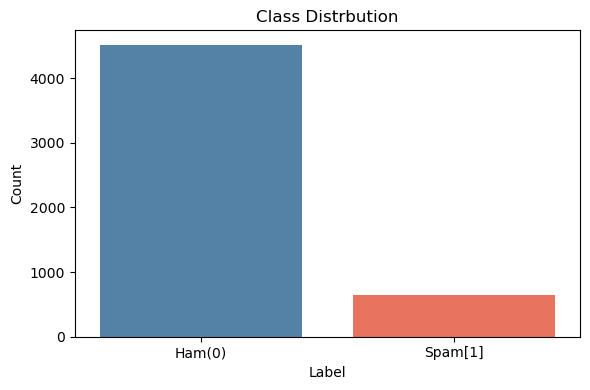

In [55]:
# 1. CLASS DISTRIBUTION 
plt.figure(figsize=(6,4))
sns.countplot(x="label",data=df,palette=["steelblue","tomato"])
plt.xticks([0,1],["Ham(0)","Spam[1]"])
plt.title("Class Distrbution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

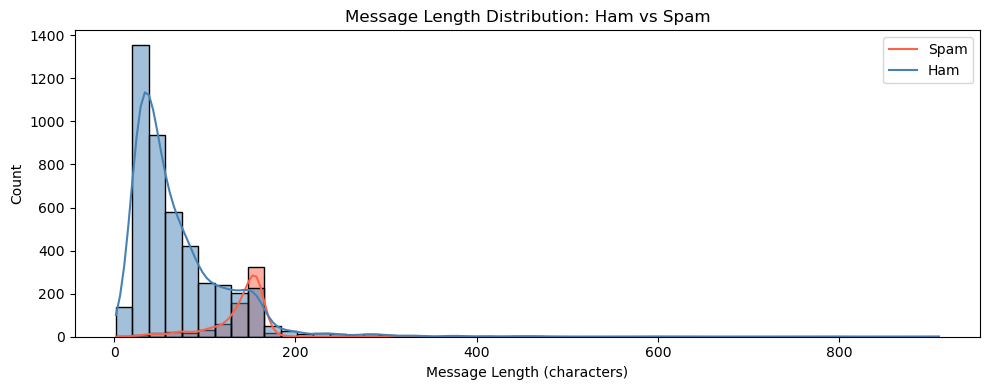

Avg Ham  message length: 70.5
Avg Spam message length: 137.9


In [56]:
# 2. MESSAGE LENGTH DISTRIBUTION
df["msg_length"] = df["message"].apply(len)
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="msg_length", hue="label", bins=50,
             palette=["steelblue", "tomato"], kde=True)
plt.title("Message Length Distribution: Ham vs Spam")
plt.xlabel("Message Length (characters)")
plt.ylabel("Count")
plt.legend(labels=["Spam", "Ham"])
plt.tight_layout()
plt.show()

print("Avg Ham  message length:", df[df["label"] == 0]["msg_length"].mean().round(1))
print("Avg Spam message length:", df[df["label"] == 1]["msg_length"].mean().round(1))

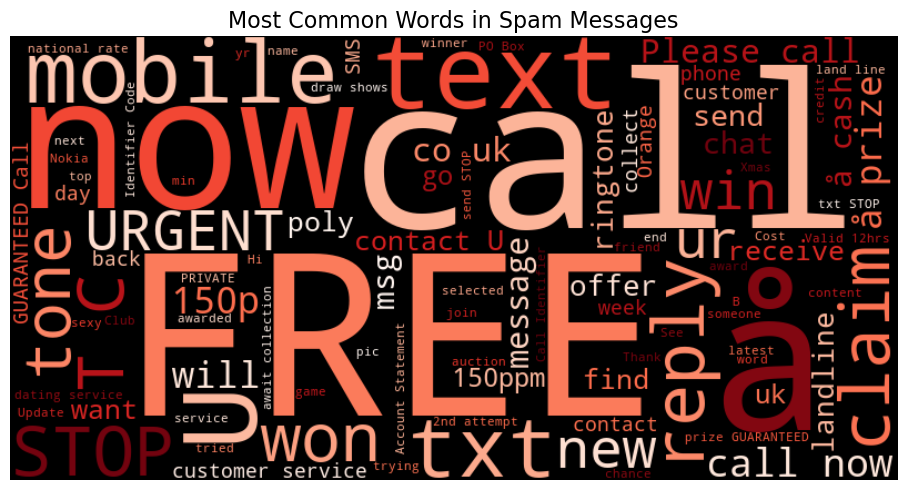

In [57]:
# 3. MOST COMMON SPAM WORDS
spam_text = " ".join(df[df["label"] == 1]["message"].tolist())
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "u","ur","txt","mobile","call","now","free"
])
wordcloud = WordCloud(
    width=800, height=400,
    background_color="black",
    colormap="Reds",
    max_words=100
).generate(spam_text)
plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Messages", fontsize=16)
plt.tight_layout()
plt.show()

#### NLP PREPROCESSING


In [58]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))
def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove punctuation
    3. Tokenize
    4. Remove stopwords
    5. Stem each token
    Returns cleaned string.
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Step 3: Tokenize
    tokens = text.split()

    # Step 4: Remove stopwords + Step 5: Stem
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

df["clean_message"] = df["message"].apply(preprocess_text)

print("Original  :", df["message"].iloc[0])
print("Processed :", df["clean_message"].iloc[0])

Original  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Processed : go jurong point crazi avail bugi n great world la e buffet cine got amor wat


##### FEATURE EXTRACTION AND TRAINING AND TESTING DATA SPLIT


In [59]:
X = df["clean_message"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 4135
Testing  samples : 1034


In [60]:
count_vec = CountVectorizer(max_features=5000)
tfidf_vec = TfidfVectorizer(max_features=5000)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv  = count_vec.transform(X_test)
X_train_tf = tfidf_vec.fit_transform(X_train)
X_test_tf  = tfidf_vec.transform(X_test)

print("CountVectorizer shape  :", X_train_cv.shape)
print("TF-IDF Vectorizer shape:", X_train_tf.shape)

CountVectorizer shape  : (4135, 5000)
TF-IDF Vectorizer shape: (4135, 5000)


#### MODEL TRAINING AND EVALUATION

In [61]:

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and return evaluation metrics as a dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_te, y_pred),  4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall"   : round(recall_score(y_te, y_pred),    4),
        "F1 Score" : round(f1_score(y_te, y_pred),        4),
    }


models = {
    "Naive Bayes"        : MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (LinearSVC)"    : LinearSVC(max_iter=1000),
}


results = []

for model_name, model in models.items():
    
    res_cv = evaluate_model(
        f"{model_name} + CountVec",
        model, X_train_cv, X_test_cv, y_train, y_test
    )
    results.append(res_cv)

    
    model2 = type(model)(**model.get_params())
    res_tf = evaluate_model(
        f"{model_name} + TF-IDF",
        model2, X_train_tf, X_test_tf, y_train, y_test
    )
    results.append(res_tf)

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
5,SVM (LinearSVC) + TF-IDF,0.9826,0.9829,0.8779,0.9274
4,SVM (LinearSVC) + CountVec,0.9816,0.9828,0.8702,0.9231
2,Logistic Regression + CountVec,0.9807,1.0000,0.8473,0.9174
0,Naive Bayes + CountVec,0.9787,0.9291,0.9008,0.9147
1,Naive Bayes + TF-IDF,0.9662,0.9898,0.7405,0.8472
3,Logistic Regression + TF-IDF,0.9632,1.0000,0.7099,0.8304


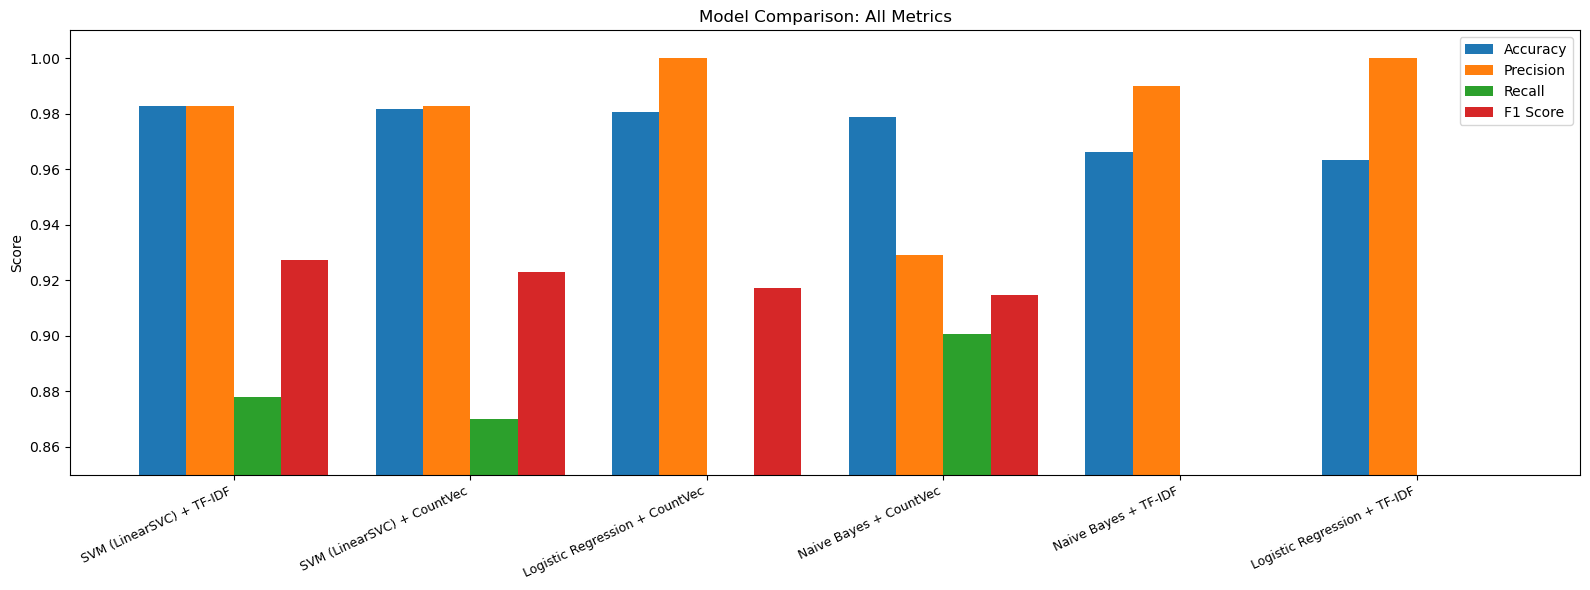

In [62]:

metrics   = ["Accuracy", "Precision", "Recall", "F1 Score"]
x         = np.arange(len(results_df))
bar_width = 0.2
fig, ax = plt.subplots(figsize=(16, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * bar_width, results_df[metric], width=bar_width, label=metric)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=25, ha="right", fontsize=9)
ax.set_ylim(0.85, 1.01)
ax.set_title("Model Comparison: All Metrics")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

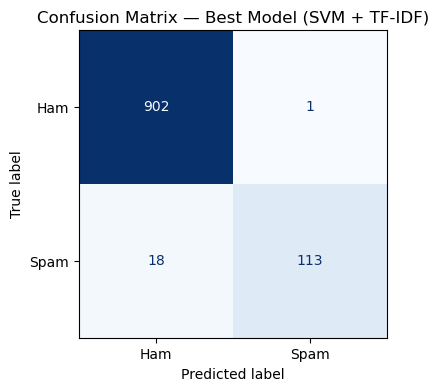

In [63]:
from sklearn.svm import SVC  
best_model = SVC(kernel="linear", probability=True)  
best_model.fit(X_train_tf, y_train)
y_pred_best = best_model.predict(X_test_tf)
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Best Model (SVM + TF-IDF)") 
plt.show()

#### PIPELINE

In [64]:
# build final model (TF-IDF + linear SVM)
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", SVC(kernel="linear", probability=True))
])

final_pipeline.fit(X_train, y_train)

# evaluate
pred = final_pipeline.predict(X_test)

print("F1 score:", round(f1_score(y_test, pred), 4))
print("Accuracy:", round(accuracy_score(y_test, pred), 4))

# save model
os.makedirs("../models", exist_ok=True)
joblib.dump(final_pipeline, "../models/spam_classifier_pipeline.pkl")
print("model saved")

F1 score: 0.9224
Accuracy: 0.9816
model saved


In [68]:
import joblib

joblib.dump(final_pipeline,
            "/Users/anushmita/spam-email-classifier/models/spam_classifier_pipeline.pkl")

print("model saved")

model saved


####

####

###